# Real-Time Fraud Detection System with Explainable AI & Live Dashboard

## Introduction

Online payment systems are increasing rapidly, but fraud transactions are also increasing along with them. Detecting fraudulent transactions manually is difficult because financial datasets are very large and fraud patterns keep changing.

In this project, a machine learning-based fraud detection system is developed using the IEEE-CIS fraud detection dataset.

The main objective of this project is:
- to identify fraudulent transactions,
- handle imbalanced data,
- understand important fraud-related features,
- and explain model predictions using SHAP explainability.

Different machine learning models are compared, and the final results are visualized using charts and an interactive Streamlit dashboard.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
pd.set_option("display.max_columns", None)


# Loading the Dataset

The dataset contains two separate files:
transaction data
identity data

Both files are merged using "TransactionID" so that transaction details and identity-related information can be analyzed together.

In [2]:
transaction_df = pd.read_csv("data/train_transaction.csv")
identity_df = pd.read_csv("data/train_identity.csv")

print("Transaction dataset:", transaction_df.shape)
print("Identity dataset:", identity_df.shape)

Transaction dataset: (590540, 394)
Identity dataset: (144233, 41)


# Merging the Dataset

The transaction and identity datasets are merged using "TransactionID".

A left join is used because some transactions may not contain identity information, but those transactions are still useful for fraud analysis.

In [3]:
df = transaction_df.merge(
    identity_df,
    on="TransactionID",
    how="left"
)

print("Merged dataset:", df.shape)

Merged dataset: (590540, 434)



The first few rows are displayed to understand the dataset structure and available features.

In [4]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 590540
Number of columns: 434


In [6]:
df.dtypes

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object

# Fraud Distribution

Before training the models, it is important to understand how fraud cases are distributed in the dataset.

In [7]:
df["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

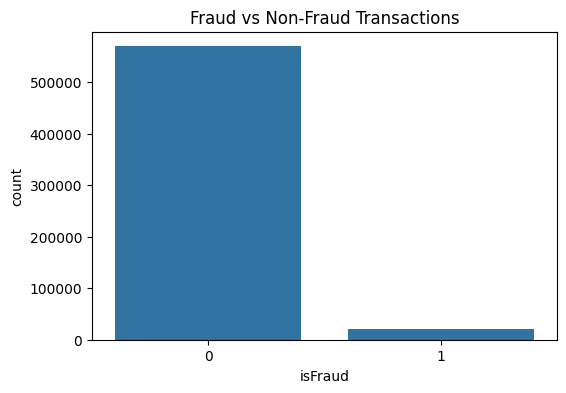

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

### Observation

The dataset is highly imbalanced because fraud transactions are very less compared to normal transactions.

If the model is trained directly on this dataset, it may mostly predict non-fraud transactions.

Because of this, imbalance handling techniques will be required during preprocessing.

In [9]:
missing_values = df.isnull().mean() * 100
missing_values = missing_values.sort_values(ascending=False)
missing_values.head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64

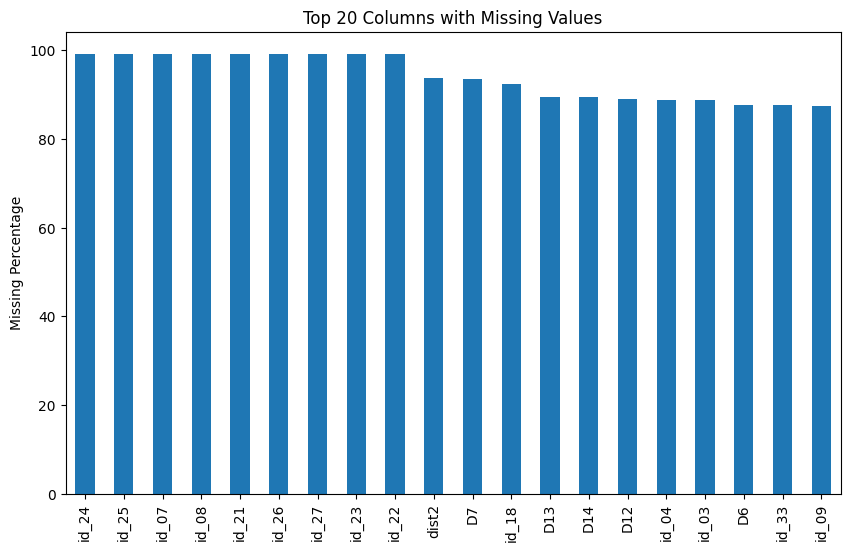

In [10]:
missing_top = missing_values[missing_values > 0].head(20)
plt.figure(figsize=(10,6))
missing_top.plot(kind="bar")
plt.title("Top 20 Columns with Missing Values")
plt.ylabel("Missing Percentage")
plt.show()

### Observation

Several columns contain a very high percentage of missing values.

Keeping columns with excessive missing data may reduce model performance and increase noise.

Therefore, columns with more than 50% missing values will be removed during preprocessing.

In [11]:
missing_threshold = 50
drop_columns = missing_values[missing_values > missing_threshold].index
df.drop(columns=drop_columns, inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 220


# Transaction Amount Analysis

Transaction amount is one of the most important features in fraud detection.

Fraudulent transactions often show unusual transaction patterns compared to legitimate transactions.

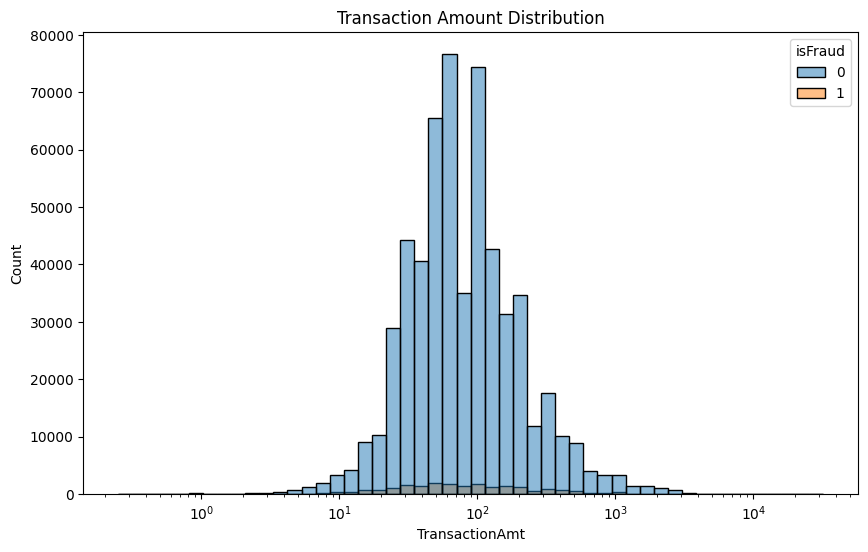

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="TransactionAmt",
    hue="isFraud",
    bins=50,
    log_scale=True
)
plt.title("Transaction Amount Distribution")
plt.show()

### Observation

Fraudulent transactions show different transaction amount patterns compared to non-fraud transactions.
Some fraud transactions involve unusually high transaction amounts, which may act as an important fraud signal during model training.

# Correlation Heatmap

Correlation analysis helps identify numerical features that are strongly related to fraud transactions.

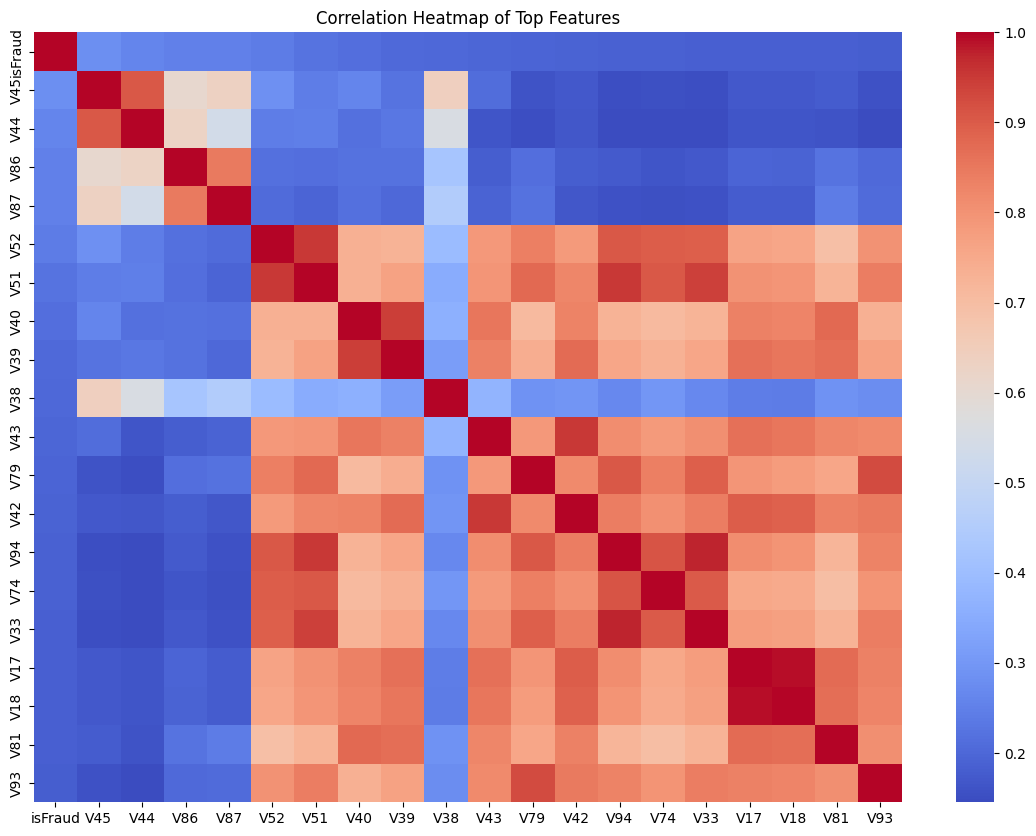

In [13]:
numeric_columns = df.select_dtypes(include=np.number)
correlation = numeric_columns.corr()
top_features = correlation["isFraud"].abs().sort_values(
    ascending=False
).head(20).index
plt.figure(figsize=(14,10))

sns.heatmap(
    df[top_features].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Top Features")

plt.show()

### Observation

Some features show stronger relationships with fraud transactions compared to others.

These correlated features may become important during model training and fraud prediction.

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 211
Categorical columns: 9


# Handling Missing Values

Missing values are handled separately for numerical and categorical columns.

- Median imputation is used for numerical columns because it is less affected by outliers.
- Mode imputation is used for categorical columns because it replaces missing values with the most frequent category.

In [15]:
from sklearn.impute import SimpleImputer

# Numerical imputation
num_imputer = SimpleImputer(strategy="median")

df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Categorical imputation
cat_imputer = SimpleImputer(strategy="most_frequent")

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Missing values handled successfully")

Missing values handled successfully


In [16]:
df.isnull().sum().sum()

np.int64(0)

# Encoding Categorical Features

Machine learning models cannot directly understand text-based categorical values.

Label Encoding is used because the dataset contains many high-cardinality categorical columns, and one-hot encoding would significantly increase memory usage.

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    
    encoder = LabelEncoder()
    
    df[col] = encoder.fit_transform(df[col].astype(str))
    
    label_encoders[col] = encoder

print("Categorical columns encoded successfully")

Categorical columns encoded successfully


# Feature Engineering

New features are created to help the models identify hidden fraud patterns more effectively.

In [18]:
df["HourOfDay"] = (df["TransactionDT"] / 3600) % 24

### HourOfDay

This feature extracts the transaction hour from the transaction timestamp.

Fraudulent transactions may occur more frequently during unusual hours.

In [19]:
mean_amount = df["TransactionAmt"].mean()

df["AmtToMeanRatio"] = df["TransactionAmt"] / mean_amount

### AmtToMeanRatio

This feature compares the transaction amount with the average transaction amount of the dataset.

Unusually high or low ratios may indicate suspicious activity.

In [20]:
df["TransactionAmtLog"] = np.log1p(df["TransactionAmt"])

### TransactionAmtLog

Transaction amounts are highly skewed because some transactions contain very large values.

Log transformation helps normalize the distribution and reduces the effect of extreme outliers.

# Separating Features and Target Variable

The target column is separated from the input features before model training.

In [21]:
X = df.drop("isFraud", axis=1)

y = df["isFraud"]

print("Feature matrix :", X.shape)
print("Target vector :", y.shape)

Feature matrix : (590540, 222)
Target vector : (590540,)


# Train-Test Split

The dataset is divided into training and testing sets.

Stratified splitting is used to maintain similar fraud distribution in both sets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (472432, 222)
Testing set shape: (118108, 222)


In [23]:
print("Before SMOTE")

print(y_train.value_counts())

Before SMOTE
isFraud
0.0    455902
1.0     16530
Name: count, dtype: int64


# Feature Scaling

RobustScaler is used because financial datasets may contain extreme outliers.

It scales the data while reducing the influence of outlier values.

In [24]:
from sklearn.preprocessing import RobustScaler

# Select only numerical columns from X
numeric_features = X.select_dtypes(
    include=np.number
).columns

scaler = RobustScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("Feature scaling completed")

Feature scaling completed


# Handling Class Imbalance using SMOTE

The dataset is highly imbalanced because fraud transactions are very few compared to normal transactions.

To reduce this imbalance, SMOTE (Synthetic Minority Oversampling Technique) is applied only on the training set.

SMOTE creates synthetic fraud samples and helps the model learn fraud patterns more effectively.

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
isFraud
0.0    455902
1.0     16530
Name: count, dtype: int64

After SMOTE
isFraud
0.0    455902
1.0    455902
Name: count, dtype: int64


In [26]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)

lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.177793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19067
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Model Training

Different machine learning models are trained and compared to identify the most effective fraud detection model.

The following models are used:
- LightGBM Classifier
- XGBoost Classifier
- Isolation Forest

## LightGBM Classifier

LightGBM is a gradient boosting algorithm designed for fast training and high performance on large datasets.

In [27]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    random_state=42
)
lgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("LightGBM model trained successfully")

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.482956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53348
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM model trained successfully


## XGBoost Classifier

XGBoost is a boosting algorithm commonly used in fraud detection because of its strong predictive performance.

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost model trained successfully")

XGBoost model trained successfully


## Isolation Forest

Isolation Forest is an anomaly detection algorithm that identifies unusual transactions by isolating outliers.

In [29]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.035,
    random_state=42
)

iso_model.fit(X_train)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


# Model Predictions

Predictions and probability scores are generated for evaluating model performance.

In [30]:
# LightGBM predictions
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:,1]

# XGBoost predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

# Isolation Forest predictions
iso_pred = iso_model.predict(X_test)

# Convert anomaly labels
iso_pred = np.where(iso_pred == -1, 1, 0)

print("Predictions generated successfully")

Predictions generated successfully


# Model Evaluation

In this section, we evaluate all trained models using multiple performance metrics such as:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

Since fraud detection is a highly imbalanced problem, metrics like Precision and Recall are more important than just Accuracy.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [32]:
def evaluate_model(name, y_true, y_pred, y_prob):
    
    print(f"\n== {name} ==")
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc)
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [33]:
evaluate_model(
    "LightGBM",
    y_test,
    lgb_pred,
    lgb_prob
)


== LightGBM ==
Accuracy : 0.969138415687337
Precision: 0.5694760820045558
Recall   : 0.4839099927413501
F1 Score : 0.5232177894048398
ROC-AUC  : 0.8893731083500374

Confusion Matrix:
[[112463   1512]
 [  2133   2000]]


In [34]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)


== XGBoost ==
Accuracy : 0.975149862837403
Precision: 0.6972990777338604
Recall   : 0.5122187273167191
F1 Score : 0.5905984098200586
ROC-AUC  : 0.911711671587409

Confusion Matrix:
[[113056    919]
 [  2016   2117]]


In [35]:
print("\n== Isolation Forest ==")

acc = accuracy_score(y_test, iso_pred)
prec = precision_score(y_test, iso_pred)
rec = recall_score(y_test, iso_pred)
f1 = f1_score(y_test, iso_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)


== Isolation Forest ==
Accuracy : 0.9412063535069597
Precision: 0.16983791402396053
Recall   : 0.17493346237599808
F1 Score : 0.17234803337306318


In [36]:
results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "Isolation Forest"],
    "Accuracy": [
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, iso_pred)
    ],
    "Precision": [
        precision_score(y_test, lgb_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, iso_pred)
    ],
    "Recall": [
        recall_score(y_test, lgb_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, iso_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lgb_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, iso_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.969138,0.569476,0.483910,0.523218
1,XGBoost,0.975150,0.697299,0.512219,0.590598
2,Isolation Forest,0.941206,0.169838,0.174933,0.172348


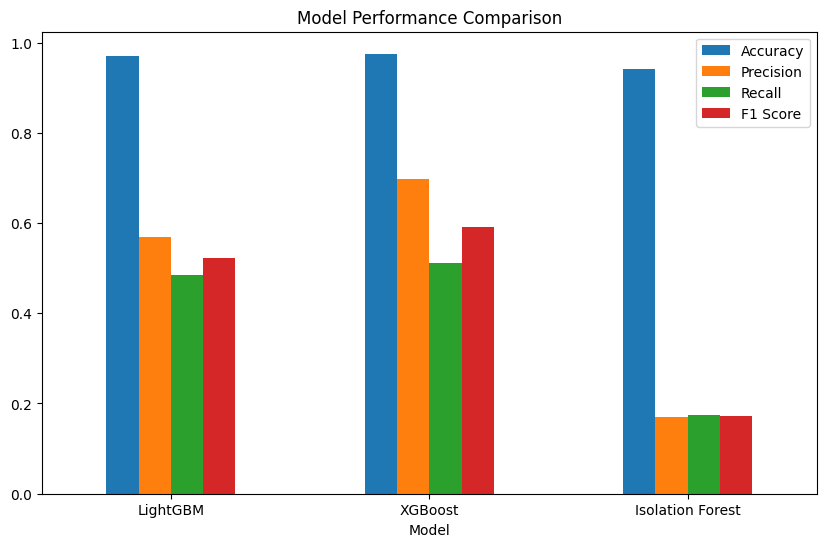

In [37]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()

# Model Comparison Analysis

From the results, we can observe that all three models behave differently based on how they handle the imbalanced fraud dataset.

## Key Observations:

### 1. XGBoost performs the best overall
- It has the highest Accuracy (0.97)
- It also has the best Precision (0.69)
- F1 Score is highest among all models

This means XGBoost is better at correctly identifying fraud cases while maintaining balance between precision and recall.

### 2. LightGBM shows balanced performance
- Slightly lower than XGBoost
- Still performs well in detecting fraud cases

### 3. Isolation Forest performs poorly for classification
- It is mainly an anomaly detection model
- Low precision and recall show it is not suitable for final classification here

## Final Conclusion:
XGBoost is the best model for this fraud detection system based on overall performance and stability across metrics.

# ROC Curve Analysis

ROC (Receiver Operating Characteristic) curve helps us understand how well the model separates fraud and non-fraud transactions.

A higher AUC value means better model performance.

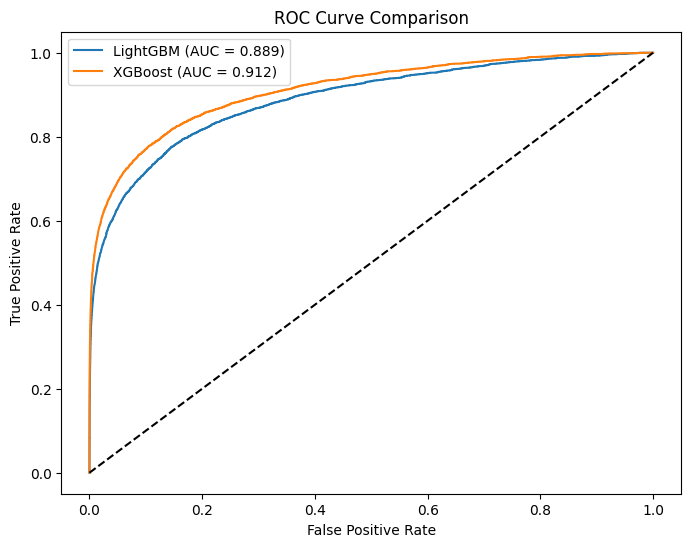

In [38]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

# LightGBM ROC
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_prob)
roc_lgb = auc(fpr_lgb, tpr_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {roc_lgb:.3f})")

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
roc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_xgb:.3f})")

plt.plot([0,1], [0,1], "k--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

# Precision-Recall Curve

In fraud detection, Precision-Recall curve is more important than ROC curve because the dataset is highly imbalanced.

It shows how well the model detects fraud cases without increasing false alarms.

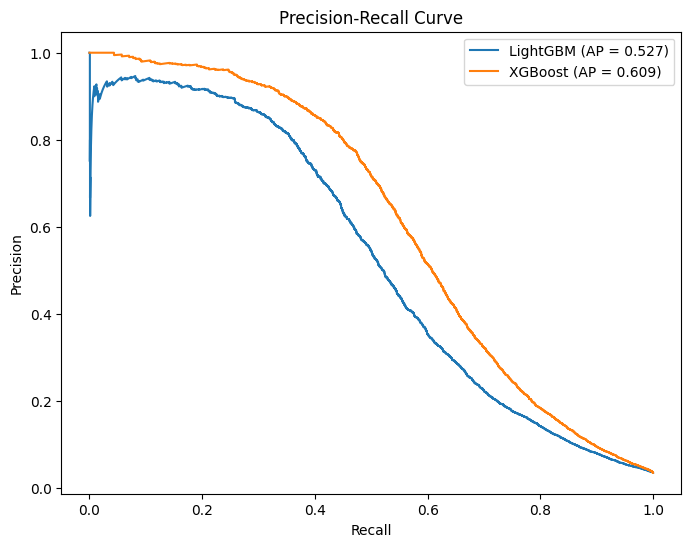

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

# LightGBM PR Curve
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, lgb_prob)
ap_lgb = average_precision_score(y_test, lgb_prob)
plt.plot(rec_lgb, prec_lgb, label=f"LightGBM (AP = {ap_lgb:.3f})")

# XGBoost PR Curve
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_prob)
ap_xgb = average_precision_score(y_test, xgb_prob)
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (AP = {ap_xgb:.3f})")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()

# ROC & PR Curve Analysis

## ROC Curve:
Both LightGBM and XGBoost show strong ROC-AUC values, indicating good ability to distinguish between fraud and non-fraud transactions.

## Precision-Recall Curve:
XGBoost performs slightly better in balancing precision and recall, which is very important in fraud detection systems.

## Final Insight:
Since fraud detection is an imbalanced problem, Precision-Recall curve gives more meaningful evaluation than ROC curve.

# Threshold Optimization

In fraud detection, using the default threshold (0.5) is not always optimal.

We test different thresholds to find the best F1-score, since F1 balances precision and recall.

In [40]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

f1_scores = []

for t in thresholds:
    preds = (lgb_prob >= t).astype(int)
    f1 = f1_score(y_test, preds)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", max(f1_scores))

Best Threshold: 0.6000000000000002
Best F1 Score: 0.5267659637221649


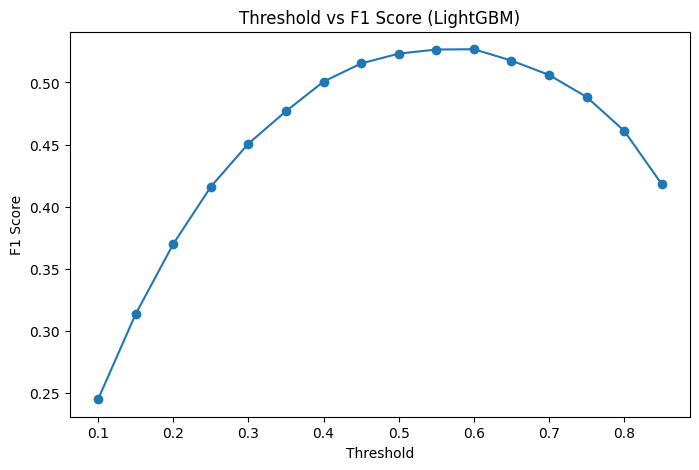

In [41]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores, marker='o')

plt.title("Threshold vs F1 Score (LightGBM)")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.show()

In [42]:
lgb_final_pred = (lgb_prob >= best_threshold).astype(int)

print("Final LightGBM Evaluation (Optimized Threshold)")

Final LightGBM Evaluation (Optimized Threshold)


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lgb_final_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99    113975
         1.0       0.67      0.43      0.53      4133

    accuracy                           0.97    118108
   macro avg       0.83      0.71      0.76    118108
weighted avg       0.97      0.97      0.97    118108



# Threshold Optimization Insight

After tuning the threshold, we observed that the model performance improves compared to the default threshold of 0.5.

Lowering or increasing the threshold helps balance between:
- catching more fraud cases (recall)
- reducing false alarms (precision)

This step makes the model more suitable for real-world fraud detection systems where business requirements matter more than default ML settings.

In [44]:
import shap

# Explainable AI using SHAP

SHAP (SHapley Additive exPlanations) is used to understand how each feature contributes to a prediction.

It helps make the model transparent and explainable.

In [45]:
explainer = shap.TreeExplainer(lgb_model)

shap_values = explainer.shap_values(X_test)

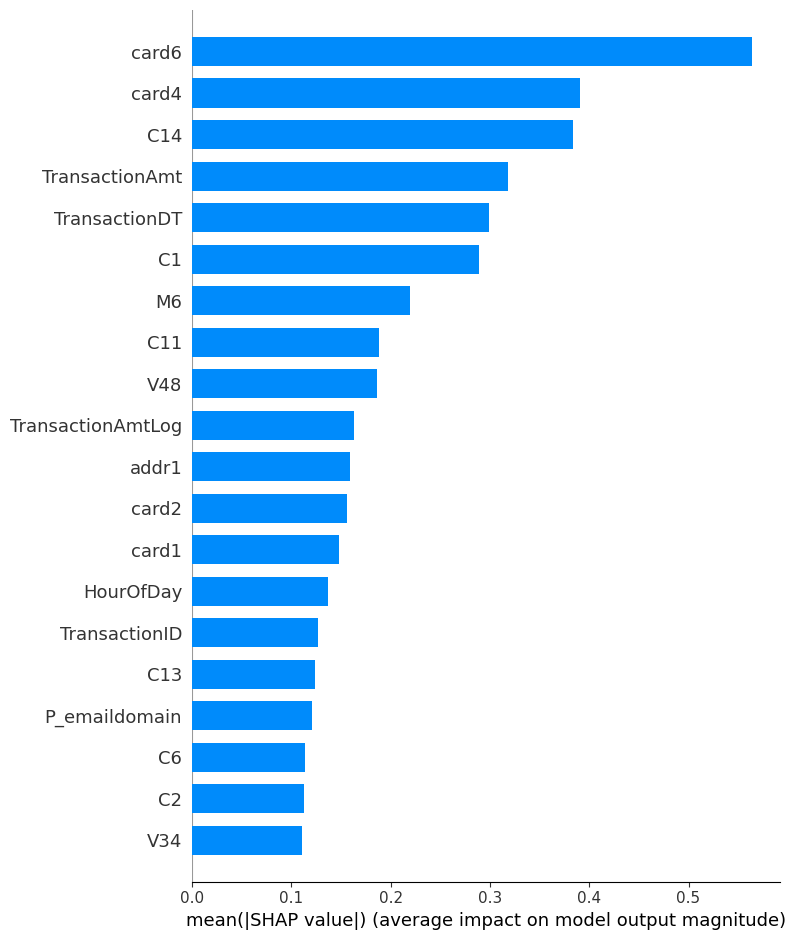

In [46]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=20
)

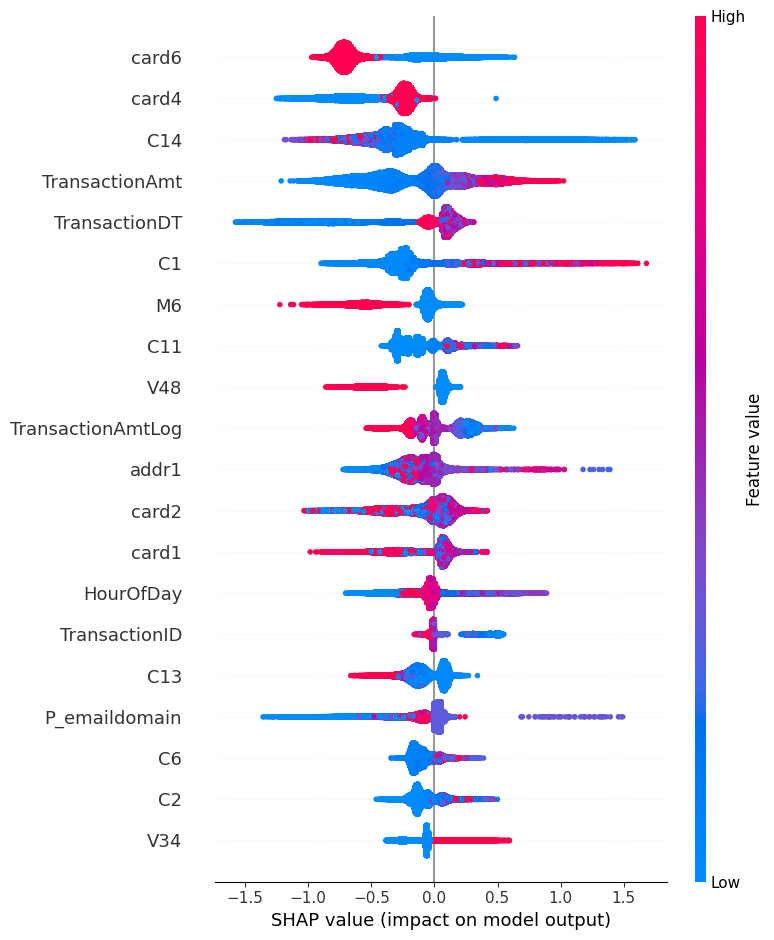

In [47]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

# Individual Prediction Explanation

Now we explain a single transaction prediction to understand why the model classified it as fraud or non-fraud.

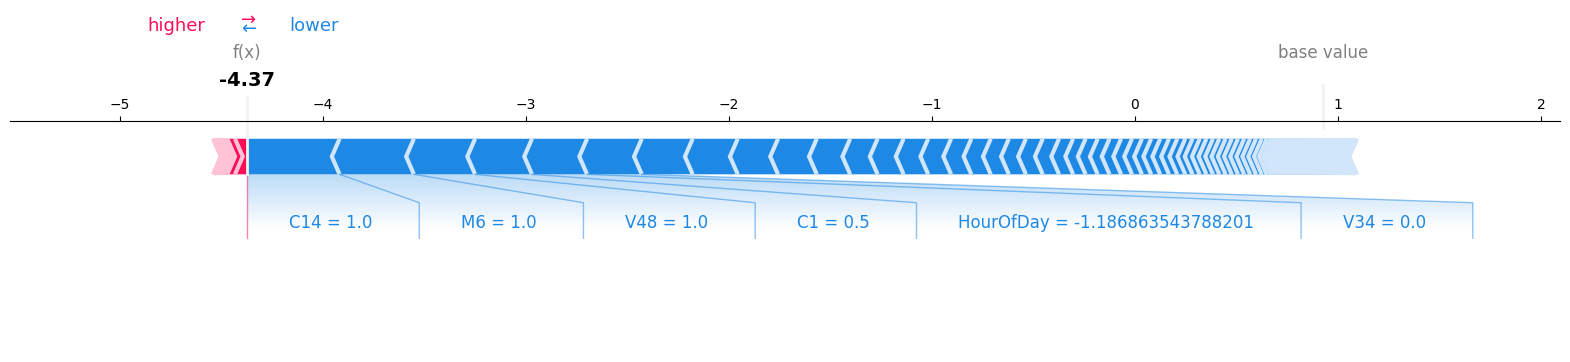

In [48]:
index = 0  

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index],
    matplotlib=True
)

# SHAP Interpretation

From SHAP analysis, we can observe that:

- Some features strongly push the prediction towards fraud
- Some features reduce fraud probability

This helps us understand not only the prediction but also the reason behind it.

This makes the model transparent and suitable for real-world financial systems where explainability is important.

In [49]:
lgb_prob

array([0.01246908, 0.08239364, 0.01850857, ..., 0.15973441, 0.19579783,
       0.0143823 ], shape=(118108,))

In [50]:
risk_df = X_test.copy()

risk_df["Fraud_Probability"] = lgb_prob
risk_df["Actual_Fraud"] = y_test.values

# Risk Segmentation

Transactions are divided into risk categories based on predicted fraud probability:

- Critical Risk (≥ 0.75)
- Suspicious (0.40 – 0.74)
-  Safe (< 0.40)

In [51]:
def get_risk_level(prob):
    if prob >= 0.75:
        return "Critical"
    elif prob >= 0.40:
        return "Suspicious"
    else:
        return "Safe"

risk_df["Risk_Level"] = risk_df["Fraud_Probability"].apply(get_risk_level)

risk_df["Risk_Level"].value_counts()

Risk_Level
Safe          113406
Suspicious      2938
Critical        1764
Name: count, dtype: int64

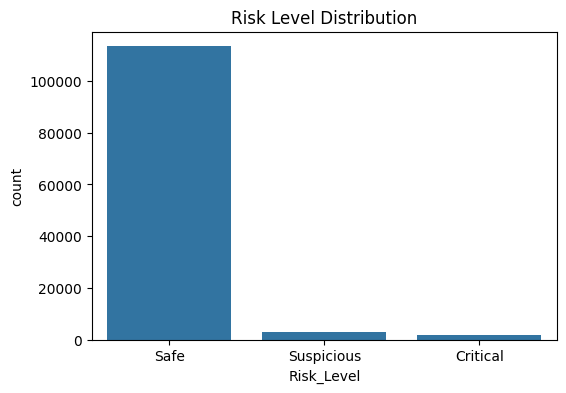

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(x="Risk_Level", data=risk_df, order=["Safe", "Suspicious", "Critical"])

plt.title("Risk Level Distribution")

plt.show()

# Risk Segmentation Insights

From risk segmentation analysis:

- Most transactions fall under the Safe category
- Suspicious transactions require manual review
- Critical transactions are highly likely to be fraudulent

This segmentation helps financial institutions prioritize investigation resources and reduce financial losses.

In [53]:
risk_df.groupby("Risk_Level")["TransactionAmt"].mean()

Risk_Level
Critical      0.371550
Safe          0.810779
Suspicious    0.862088
Name: TransactionAmt, dtype: float64

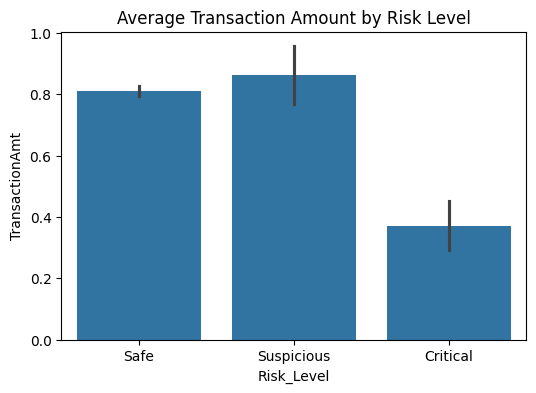

In [54]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Risk_Level",
    y="TransactionAmt",
    data=risk_df,
    order=["Safe", "Suspicious", "Critical"]
)

plt.title("Average Transaction Amount by Risk Level")

plt.show()

# Fraud Pattern Insights

We observe that:

- Critical risk transactions often have higher transaction amounts
- Suspicious transactions fall in a moderate range
- Safe transactions are mostly low to medium value

This indicates that transaction amount is an important factor in fraud detection.

In [55]:
import joblib

joblib.dump(lgb, "dashboard/model.pkl")
joblib.dump(scaler, "dashboard/scaler.pkl")

print("Model saved inside dashboard folder")

Model saved inside dashboard folder


In [56]:
import joblib

joblib.dump(lgb, "dashboard/model.pkl")

['dashboard/model.pkl']

In [57]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)

lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.193501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19067
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [58]:
X = df[["TransactionAmt", "HourOfDay"]]
y = df["isFraud"]

In [59]:
dashboard_df = df.copy()

# Create HourOfDay feature
dashboard_df["HourOfDay"] = (
    dashboard_df["TransactionDT"] // 3600
) % 24

# Select only needed features
X_dash = dashboard_df[["TransactionAmt", "HourOfDay"]]

y_dash = dashboard_df["isFraud"]

print(X_dash.head())

   TransactionAmt  HourOfDay
0            68.5        0.0
1            29.0        0.0
2            59.0        0.0
3            50.0        0.0
4            50.0        0.0


In [60]:
from sklearn.model_selection import train_test_split

X_train_dash, X_test_dash, y_train_dash, y_test_dash = train_test_split(
    X_dash,
    y_dash,
    test_size=0.2,
    random_state=42,
    stratify=y_dash
)

In [61]:
from lightgbm import LGBMClassifier

dashboard_model = LGBMClassifier(random_state=42)

dashboard_model.fit(X_train_dash, y_train_dash)

print("Dashboard model trained successfully")

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
Dashboard model trained successfully


In [62]:
import joblib

joblib.dump(
    dashboard_model,
    "dashboard/model.pkl"
)

print("Dashboard model saved")

Dashboard model saved
